## 1. Base model

In [99]:
import numpy as np
import pandas as pd

import sklearn
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.model_selection import (RandomizedSearchCV,
                                    TimeSeriesSplit,
                                    )
from sklearn.utils.class_weight import compute_sample_weight


from sklearn.linear_model import Lasso

from quantmod.timeseries import OpCl, HiLo, Gap, dailyReturn
from quantmod.indicators import SMA, BBands

# Metrics
from sklearn.metrics import (accuracy_score,
                             RocCurveDisplay,
                             ConfusionMatrixDisplay,
                             classification_report
                            )

In [2]:
df_SPY = pd.read_csv('spy.csv', index_col=0, parse_dates=True)
df_SPY = df_SPY["2010":]
# Check for missing values
df_SPY.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [3]:
display(df_SPY.shape)

(2598, 6)

**1.1 feature generation**

In [69]:
# Define Create Features
def create_features(frame):
    df = frame.copy()
    
    # Features - X
    df['OC'] = OpCl(df)
    df['HL'] = HiLo(df)
    df['GAP'] = Gap(df)
    df['RET'] = dailyReturn(df.Close)
    multiplier = 2
    
    for i in range(5, 65, 10):
        df['PCHG' + str(i)] = df['Close'].pct_change(i)
        df['VCHG' + str(i)] = df['Volume'].pct_change(i)
        df['MA' + str(i)] = SMA(df['Close'], i)
        df['VMA' + str(i)] = SMA(df['Volume'], i)
        df['OC'+ str(i)] = df['OC'].rolling(i).mean()
        df['HL'+ str(i)] = df['HL'].rolling(i).mean()
        df['GAP'+ str(i)] = df['GAP'].rolling(i).mean()
        df['STD'+ str(i)] = df['RET'].rolling(i).std()
        df['LB'+str(i)] = BBands(df['Close'], i, multiplier)[0]   
        df['UB'+str(i)] = BBands(df['Close'], i, multiplier)[2]

    # Drop unnecessary columns
    df.drop(['Open', 'High', 'Low', 'Volume'], axis=1, inplace=True)
    df.dropna(inplace=True)

    return df

In [45]:
# Features generation
x0 = create_features(df_SPY)
x0.shape

(2543, 66)

In [203]:
#7 years traing set & 1 year test set 
n=7 
x_train = x0[:n*252]
x_test =x0[n*252:(n+2)*252]

y = np.where(x0['RET']>0.0025 ,1 ,0)
y_train = y[1:n*252+1]
y_test = y[n*252+1:(n+2)*252+1]

In [47]:
x_train

,Close,Adj Close,OC,HL,GAP,RET,PCHG5,VCHG5,MA5,VMA5,...,PCHG55,VCHG55,MA55,VMA55,OC55,HL55,GAP55,STD55,LB55,UB55
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-24,116.839996,95.494675,0.130005,1.849998,-0.003748,-0.004867,-0.002220,0.104833,116.770000,197328440.0,...,0.030971,0.648436,112.128363,2.012533e+08,-0.082182,1.360364,-0.000130,0.009313,105.753048,118.503679
2010-03-25,116.650002,95.339355,0.979996,1.659996,0.006761,-0.001627,-0.003332,0.136824,116.692000,202705880.0,...,0.026578,1.002120,112.183273,2.032863e+08,-0.057636,1.375455,0.000004,0.009313,105.704091,118.662454
2010-03-26,116.580002,95.282181,0.290001,1.299995,0.001886,-0.000600,0.005260,-0.091919,116.814000,198539360.0,...,0.025240,0.773074,112.235454,2.049178e+08,-0.048909,1.388909,0.000056,0.009314,105.660655,118.810254
2010-03-29,117.320000,95.886986,-0.150002,0.839996,0.005061,0.006327,0.006261,-0.270842,116.960001,188546500.0,...,0.027410,0.026107,112.292364,2.049800e+08,-0.039091,1.383273,0.000181,0.009334,105.595587,118.989140
2010-03-30,117.400002,95.952354,0.059998,0.919998,0.001193,0.000682,-0.000085,-0.203175,116.958000,181112680.0,...,0.024701,0.153238,112.343818,2.053322e+08,-0.025636,1.382545,0.000251,0.009326,105.533223,119.154413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-03-20,236.770004,223.349350,0.259995,1.039993,0.000000,-0.001097,-0.004373,-0.082432,237.625998,75169140.0,...,0.055125,-0.180326,231.675819,7.474655e+07,-0.172729,1.263092,0.000235,0.004158,221.732758,241.618880
2017-03-21,233.729996,220.481628,3.740005,4.029999,0.002956,-0.012923,-0.013381,1.201195,236.991998,89554840.0,...,0.041810,1.706773,231.846365,7.625770e+07,-0.107093,1.317274,0.000283,0.004560,222.095305,241.597424
2017-03-22,234.279999,221.000458,-0.509995,1.559998,0.000171,0.002350,-0.019544,0.015481,236.057999,89852320.0,...,0.048092,-0.104856,232.041819,7.604989e+07,-0.138184,1.307455,0.000255,0.004524,222.542181,241.541457


**1.2 fitting model**

In [48]:
#7-3 3 20
clf_C = Pipeline([('StandardScaler',StandardScaler()),('SVC',SVC(C=3, kernel='poly', degree=3, coef0=8))])
clf_C.fit(x_train, y_train)

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('SVC', SVC(C=3, coef0=8, kernel='poly'))])

In [204]:
#predict model
y_predict_train = clf_C.predict(x_train)
y_predict_test = clf_C.predict(x_test)

In [205]:
# Accuracy Scores
acc_train = accuracy_score(y_train, y_predict_train)
acc_test = accuracy_score(y_test, y_predict_test)
print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7988, Test Accuracy: 0.6746


## 2. feature selection

**2.1 filter method**

In [70]:
# Remove highly correlated features - greater than 0.90 in this case
threshold = 0.9
corr_matrix = x0.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]


In [71]:
x1=x0.drop(to_drop, axis=1)
to_select = x1.columns.astype(str)

In [72]:
# Number of features selected
print(f"\n No. of features selected by filter method: {len(x1.columns)} \n List of features selected: {to_select}")


 No. of features selected by filter method: 31 
 List of features selected: Index(['Close', 'OC', 'HL', 'GAP', 'RET', 'PCHG5', 'VCHG5', 'VMA5', 'OC5',
       'HL5', 'GAP5', 'STD5', 'PCHG15', 'VCHG15', 'OC15', 'GAP15', 'STD15',
       'PCHG25', 'VCHG25', 'OC25', 'GAP25', 'PCHG35', 'VCHG35', 'OC35',
       'GAP35', 'PCHG45', 'VCHG45', 'OC45', 'PCHG55', 'VCHG55', 'OC55'],
      dtype='object')


**2.2 embedded method**

In [73]:
xla = x1.copy()
#scale daily return
Scaler=StandardScaler()

Scaler.fit(xla[['RET']])
y_la=Scaler.transform(xla[['RET']])
y_train_lasso=y_la[1:n*252+1]

x_train_lasso=xla[:n*252]

In [74]:
#LASSO
coef = []
alpha_range = np.logspace(-1, -2, 200)#10^-2 to 10^-1, 200 number
for alpha in alpha_range:
    # Define pipeline
    lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=alpha, max_iter=1000000))
    ])

    # Fit pipeline on training data
    lasso.fit(x_train_lasso, y_train_lasso)

    # Store coefficients
    coef.append(lasso.named_steps['regressor'].coef_)

# Create DataFrame: rows = alphas, columns = features
coef_df = pd.DataFrame(coef, columns=xla.columns, index=alpha_range)
coef_df.index.name = 'alpha'

In [75]:
coef_df.tail(50)

,Close,OC,HL,GAP,RET,PCHG5,VCHG5,VMA5,OC5,HL5,...,PCHG35,VCHG35,OC35,GAP35,PCHG45,VCHG45,OC45,PCHG55,VCHG55,OC55
alpha,,,,,,,,,,,,,,,,,,,,,
0.017629,-0.000000,0.016266,-0.026970,0.0,-0.0,-0.043567,-0.0,0.0,0.0,0.019588,...,-0.018545,-0.000540,0.0,-0.0,0.000000,0.0,-0.000000,-0.005032,-0.000000,0.007122
0.017426,-0.000000,0.016423,-0.027781,0.0,-0.0,-0.043715,-0.0,0.0,0.0,0.020151,...,-0.018836,-0.001086,0.0,-0.0,0.000000,0.0,-0.000000,-0.004899,-0.000000,0.007276
0.017226,-0.000000,0.016578,-0.028583,0.0,-0.0,-0.043862,-0.0,0.0,0.0,0.020707,...,-0.019124,-0.001627,0.0,-0.0,0.000000,0.0,-0.000000,-0.004767,-0.000000,0.007427
0.017028,-0.000000,0.016732,-0.029376,0.0,-0.0,-0.044007,-0.0,0.0,0.0,0.021257,...,-0.019409,-0.002161,0.0,-0.0,0.000000,0.0,-0.000000,-0.004638,-0.000000,0.007577
0.016832,-0.000000,0.016884,-0.030160,0.0,-0.0,-0.044150,-0.0,0.0,0.0,0.021800,...,-0.019690,-0.002689,0.0,-0.0,0.000000,0.0,-0.000000,-0.004509,-0.000000,0.007725
0.016638,-0.000000,0.017034,-0.030935,0.0,-0.0,-0.044292,-0.0,0.0,0.0,0.022337,...,-0.019968,-0.003211,0.0,-0.0,0.000000,0.0,-0.000000,-0.004382,-0.000000,0.007872
0.016447,-0.000000,0.017182,-0.031701,0.0,-0.0,-0.044432,-0.0,0.0,0.0,0.022868,...,-0.020243,-0.003727,0.0,-0.0,0.000000,0.0,-0.000000,-0.004257,-0.000000,0.008016
0.016258,-0.000000,0.017329,-0.032458,0.0,-0.0,-0.044571,-0.0,0.0,0.0,0.023393,...,-0.020515,-0.004237,0.0,-0.0,0.000000,0.0,-0.000000,-0.004132,-0.000000,0.008159
0.016071,-0.000000,0.017474,-0.033207,0.0,-0.0,-0.044707,-0.0,0.0,0.0,0.023911,...,-0.020783,-0.004741,0.0,-0.0,0.000000,0.0,-0.000000,-0.004010,-0.000000,0.008301


In [76]:
lasso = Pipeline([('scaler', StandardScaler()),('regressor', Lasso(alpha=0.01020))])
lasso.fit(x_train_lasso, y_train_lasso)
coef_lasso=lasso.named_steps['regressor'].coef_
coef_lasso

array([-0.00067332,  0.02331129, -0.05582408,  0.        , -0.        ,
       -0.04634054, -0.        , -0.        ,  0.        ,  0.04100976,
       -0.00669926,  0.        , -0.        ,  0.02603311, -0.        ,
       -0.01022708,  0.        , -0.        , -0.        , -0.        ,
        0.        , -0.03725039, -0.02040955,  0.        , -0.        ,
        0.00419432,  0.        , -0.0175381 , -0.        , -0.00470582,
        0.02773207])

In [77]:
column_indices = np.where(coef_lasso)[0]
x2=xla.iloc[:, column_indices]
x2

,Close,OC,HL,PCHG5,HL5,GAP5,VCHG15,GAP15,PCHG35,VCHG35,PCHG45,OC45,VCHG55,OC55
Date,,,,,,,,,,,,,,
2010-03-24,116.839996,0.130005,1.849998,-0.002220,1.402002,-0.003407,0.300346,-0.000376,0.058525,-0.093632,0.015470,-0.039778,0.648436,-0.082182
2010-03-25,116.650002,0.979996,1.659996,-0.003332,1.594002,-0.002072,0.645398,-0.000015,0.062096,0.293321,0.024234,-0.026667,1.002120,-0.057636
2010-03-26,116.580002,0.290001,1.299995,0.005260,1.500000,0.000133,0.168578,-0.000321,0.095265,-0.423046,0.043688,-0.069555,0.773074,-0.048909
2010-03-29,117.320000,-0.150002,0.839996,0.006261,1.355998,0.002284,0.173446,0.000011,0.099944,-0.727477,0.074261,-0.117111,0.026107,-0.039091
2010-03-30,117.400002,0.059998,0.919998,-0.000085,1.313997,0.002231,-0.056835,0.000289,0.108698,-0.349714,0.069509,-0.125556,0.153238,-0.025636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-23,279.079987,1.410004,5.190002,-0.000072,5.128003,0.003122,-0.447601,0.006923,-0.107972,-0.407125,-0.175149,-0.207113,0.673395,-0.264729
2020-04-24,282.970001,-2.239990,5.200012,-0.012804,5.188007,-0.000196,-0.520625,0.007577,-0.064438,-0.543019,-0.160202,-0.274446,0.291351,-0.294729
2020-04-27,287.049988,-1.929993,3.649994,0.019390,4.830005,0.004136,-0.425377,0.008367,-0.034996,-0.659345,-0.139229,-0.361556,0.546804,-0.328547


In [78]:
# Number of features selected
print(f"\n No. of features selected by filter method and embedded method: {len(x2.columns)} \n List of features selected: {x2.columns}")


 No. of features selected by filter method and embedded method: 14 
 List of features selected: Index(['Close', 'OC', 'HL', 'PCHG5', 'HL5', 'GAP5', 'VCHG15', 'GAP15',
       'PCHG35', 'VCHG35', 'PCHG45', 'OC45', 'VCHG55', 'OC55'],
      dtype='object')


**2.3 wrapper method**

In [79]:
xwrp = x2.copy()

x_train_wrapper=xwrp[:n*252]

In [80]:
tscv = TimeSeriesSplit(n_splits=n-1, gap=0)

clf_wrapper = Pipeline([('StandardScaler',StandardScaler()),('SVC',SVC(C=3, kernel='poly', degree=3, coef0=8))])
clf_wrapper_FS = SequentialFeatureSelector(clf_wrapper, n_features_to_select=12, direction='backward',cv=tscv, scoring='accuracy', n_jobs=-1)
clf_wrapper_FS.fit(x_train_wrapper,y_train)

SequentialFeatureSelector(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=6, test_size=None),
                          direction='backward',
                          estimator=Pipeline(steps=[('StandardScaler',
                                                     StandardScaler()),
                                                    ('SVC',
                                                     SVC(C=3, coef0=8,
                                                         kernel='poly'))]),
                          n_features_to_select=12, n_jobs=-1,
                          scoring='accuracy')

In [81]:
x3=x2.iloc[:, clf_wrapper_FS.get_support(indices=True)]
x3

,Close,OC,HL,PCHG5,HL5,GAP5,VCHG15,GAP15,PCHG35,PCHG45,OC45,VCHG55
Date,,,,,,,,,,,,
2010-03-24,116.839996,0.130005,1.849998,-0.002220,1.402002,-0.003407,0.300346,-0.000376,0.058525,0.015470,-0.039778,0.648436
2010-03-25,116.650002,0.979996,1.659996,-0.003332,1.594002,-0.002072,0.645398,-0.000015,0.062096,0.024234,-0.026667,1.002120
2010-03-26,116.580002,0.290001,1.299995,0.005260,1.500000,0.000133,0.168578,-0.000321,0.095265,0.043688,-0.069555,0.773074
2010-03-29,117.320000,-0.150002,0.839996,0.006261,1.355998,0.002284,0.173446,0.000011,0.099944,0.074261,-0.117111,0.026107
2010-03-30,117.400002,0.059998,0.919998,-0.000085,1.313997,0.002231,-0.056835,0.000289,0.108698,0.069509,-0.125556,0.153238
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-23,279.079987,1.410004,5.190002,-0.000072,5.128003,0.003122,-0.447601,0.006923,-0.107972,-0.175149,-0.207113,0.673395
2020-04-24,282.970001,-2.239990,5.200012,-0.012804,5.188007,-0.000196,-0.520625,0.007577,-0.064438,-0.160202,-0.274446,0.291351
2020-04-27,287.049988,-1.929993,3.649994,0.019390,4.830005,0.004136,-0.425377,0.008367,-0.034996,-0.139229,-0.361556,0.546804


In [100]:
# Number of features selected
print(f"\n No. of features selected combining filter method, embedded method, and wrapper method {len(x3.columns)} \n List of features selected: {x3.columns}")


 No. of features selected combining filter method, embedded method, and wrapper method 13 
 List of features selected: Index(['Close', 'OC', 'HL', 'PCHG5', 'HL5', 'GAP5', 'VCHG15', 'GAP15',
       'PCHG35', 'PCHG45', 'OC45', 'VCHG55', 'OC55'],
      dtype='object')


In [83]:
tscv = TimeSeriesSplit(n_splits=n-1, gap=0)

clf_wrapper = Pipeline([('StandardScaler',StandardScaler()),('SVC',SVC(C=3, kernel='poly', degree=3, coef0=8))])
clf_wrapper_FS = SequentialFeatureSelector(clf_wrapper, tol=0.05, direction='backward',cv=tscv, scoring='accuracy', n_jobs=-1)
clf_wrapper_FS.fit(x_train_wrapper,y_train)

SequentialFeatureSelector(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=6, test_size=None),
                          direction='backward',
                          estimator=Pipeline(steps=[('StandardScaler',
                                                     StandardScaler()),
                                                    ('SVC',
                                                     SVC(C=3, coef0=8,
                                                         kernel='poly'))]),
                          n_jobs=-1, scoring='accuracy', tol=0.05)

In [84]:
x3=x2.iloc[:, clf_wrapper_FS.get_support(indices=True)]
x3

,Close,OC,HL,PCHG5,HL5,GAP5,VCHG15,GAP15,PCHG35,PCHG45,OC45,VCHG55,OC55
Date,,,,,,,,,,,,,
2010-03-24,116.839996,0.130005,1.849998,-0.002220,1.402002,-0.003407,0.300346,-0.000376,0.058525,0.015470,-0.039778,0.648436,-0.082182
2010-03-25,116.650002,0.979996,1.659996,-0.003332,1.594002,-0.002072,0.645398,-0.000015,0.062096,0.024234,-0.026667,1.002120,-0.057636
2010-03-26,116.580002,0.290001,1.299995,0.005260,1.500000,0.000133,0.168578,-0.000321,0.095265,0.043688,-0.069555,0.773074,-0.048909
2010-03-29,117.320000,-0.150002,0.839996,0.006261,1.355998,0.002284,0.173446,0.000011,0.099944,0.074261,-0.117111,0.026107,-0.039091
2010-03-30,117.400002,0.059998,0.919998,-0.000085,1.313997,0.002231,-0.056835,0.000289,0.108698,0.069509,-0.125556,0.153238,-0.025636
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-23,279.079987,1.410004,5.190002,-0.000072,5.128003,0.003122,-0.447601,0.006923,-0.107972,-0.175149,-0.207113,0.673395,-0.264729
2020-04-24,282.970001,-2.239990,5.200012,-0.012804,5.188007,-0.000196,-0.520625,0.007577,-0.064438,-0.160202,-0.274446,0.291351,-0.294729
2020-04-27,287.049988,-1.929993,3.649994,0.019390,4.830005,0.004136,-0.425377,0.008367,-0.034996,-0.139229,-0.361556,0.546804,-0.328547


In [87]:
# Number of features selected
print(f"\n No. of features selected combining filter method, embedded method, and wrapper method {len(x3.columns)} \n List of features selected: {x3.columns}")


 No. of features selected combining filter method, embedded method, and wrapper method 13 
 List of features selected: Index(['Close', 'OC', 'HL', 'PCHG5', 'HL5', 'GAP5', 'VCHG15', 'GAP15',
       'PCHG35', 'PCHG45', 'OC45', 'VCHG55', 'OC55'],
      dtype='object')


## 3. tuning hyperparameters

In [208]:
x_train = x3[:n*252]
x_test =x3[n*252:(n+2)*252]

In [89]:
tscv = TimeSeriesSplit(n_splits=n-1, gap=0) #for the nth split,n set train set and n+1th test set ,set size =252*8/(8+1)

**3.1 tuning model based on polynominal kernel**

In [178]:
# Hyper parameter optimization
param_grid_1 = {
    'C': [7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    'degree': [3],
    'coef0': [14, 16, 18, 20, 22, 24, 26, 28, 30],
    'kernel': ['poly'],
    'class_weight': ['balanced']
}

In [179]:
# perform random search
rs_1 = RandomizedSearchCV(
    SVC(), #estimator 不用pipeline 直接用estimator？
    param_grid_1,
    n_iter=25,
    scoring='balanced_accuracy',#是否更换scoring 指标 什么是roc_auc？
    cv=tscv,
    verbose=0,
    n_jobs=-1
)

rs_1.fit(
    x_train,
    y_train,
#    sample_weight=sample_weights
)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=6, test_size=None),
                   estimator=SVC(), n_iter=25, n_jobs=-1,
                   param_distributions={'C': [7, 8, 9, 10, 11, 12, 13, 14, 15,
                                              16],
                                        'class_weight': ['balanced'],
                                        'coef0': [14, 16, 18, 20, 22, 24, 26,
                                                  28, 30],
                                        'degree': [3], 'kernel': ['poly']},
                   scoring='balanced_accuracy')

In [180]:
# Print best parameters
print("\nBest parameters found by RandomizedSearchCV:")
print(rs_1.best_params_)
print(f"Best score: {rs_1.best_score_:.4f}")


Best parameters found by RandomizedSearchCV:
{'kernel': 'poly', 'degree': 3, 'coef0': 30, 'class_weight': 'balanced', 'C': 16}
Best score: 0.5510


In [181]:
# Get the best hyperparameters
best_params = rs_1.best_params_
clf_tuned_1 = Pipeline([('StandardScaler',StandardScaler()),('SVC',SVC(**best_params))])
clf_tuned_1.fit(x_train, y_train)

Exception ignored in: <function ResourceTracker.__del__ at 0x7f85508fe0>
Traceback (most recent call last):
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f94c6cfe0>
Traceback (most recent call last):
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/LWJ/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f7cdd4fe0>

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('SVC',
                 SVC(C=16, class_weight='balanced', coef0=30, kernel='poly'))])

In [189]:
#predict model
y_predict_train_1 = clf_tuned_1.predict(x_train)
y_predict_test_1 = clf_tuned_1.predict(x_test)

In [216]:
# Accuracy Scores
acc_train = accuracy_score(y_train, y_predict_train_1)
acc_test = accuracy_score(y_test, y_predict_test_1)
print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7296, Test Accuracy: 0.6448


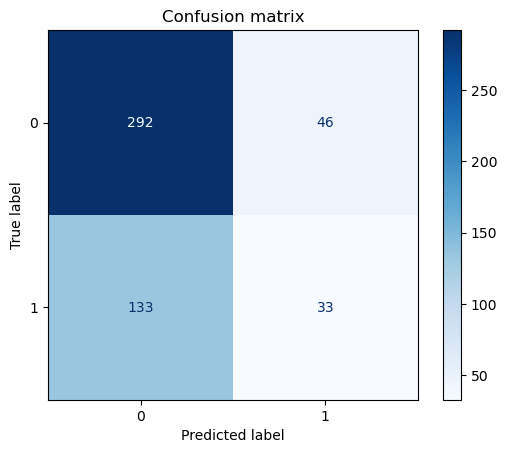

In [217]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        clf_tuned_1,
        x_test,
        y_test,
        display_labels=clf_tuned_1.classes_,
        cmap=plt.cm.Blues
    )
disp.ax_.set_title('Confusion matrix')
plt.show()

In [215]:
# Classification Report
print(classification_report(y_test, y_predict_test_1))

              precision    recall  f1-score   support

           0       0.69      0.86      0.77       338
           1       0.42      0.20      0.27       166

    accuracy                           0.64       504
   macro avg       0.55      0.53      0.52       504
weighted avg       0.60      0.64      0.60       504



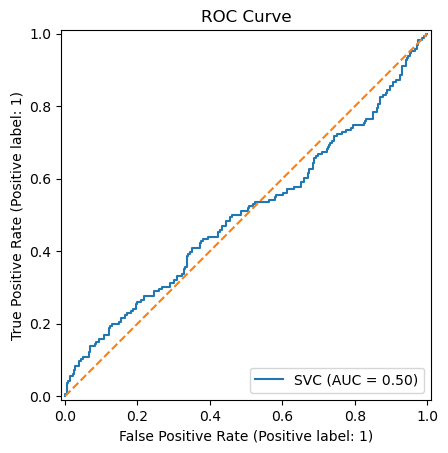

In [214]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
            clf_tuned_1,
            x_test,
            y_test,
            name='SVC')
disp_roc.ax_.set_title('ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')
plt.show()

**3.2 tuning model based on rbf kernel**

In [146]:
# Hyper parameter optimization
param_grid_2 = {
    'C': [0.4, 0.6, 0.8, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

In [169]:
# perform random search
rs_2 = RandomizedSearchCV(
    SVC(), #estimator 不用pipeline 直接用estimator？
#    clf_C,
    param_grid_2,
    n_iter=18,
    scoring='balanced_accuracy',
    cv=tscv,
    verbose=0,
    n_jobs=-1
)

rs_2.fit(
    x_train,
    y_train,
#    sample_weight=sample_weights
)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=6, test_size=None),
                   estimator=SVC(), n_iter=18, n_jobs=-1,
                   param_distributions={'C': [0.4, 0.6, 0.8, 1, 2, 3, 4, 5, 6,
                                              7, 8, 9, 10, 11, 12, 13, 14, 15],
                                        'class_weight': ['balanced'],
                                        'kernel': ['rbf']},
                   scoring='balanced_accuracy')

In [170]:
# Print best parameters
print("\nBest parameters found by RandomizedSearchCV:")
print(rs_2.best_params_)
print(f"Best score: {rs_2.best_score_:.4f}")


Best parameters found by RandomizedSearchCV:
{'kernel': 'rbf', 'class_weight': 'balanced', 'C': 5}
Best score: 0.5102


In [171]:
# Get the best hyperparameters
best_params = rs_2.best_params_
clf_tuned_2 = Pipeline([('StandardScaler',StandardScaler()),('SVC',SVC(**best_params))])
clf_tuned_2.fit(x_train, y_train)

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('SVC', SVC(C=5, class_weight='balanced'))])

In [193]:
#predict model
y_predict_train_2 = clf_tuned_2.predict(x_train)
y_predict_test_2 = clf_tuned_2.predict(x_test)

In [198]:
# Accuracy Scores
acc_train = accuracy_score(y_train, y_predict_train_2)
acc_test = accuracy_score(y_test, y_predict_test_2)
print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7319, Test Accuracy: 0.6607


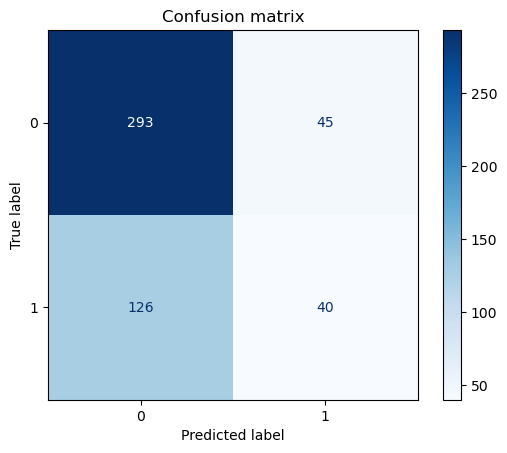

In [199]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        clf_tuned_2,
        x_test,
        y_test,
        display_labels=clf_tuned_2.classes_,
        cmap=plt.cm.Blues
    )
disp.ax_.set_title('Confusion matrix')
plt.show()

In [196]:
# Classification Report
print(classification_report(y_test, y_predict_test_2))

              precision    recall  f1-score   support

           0       0.70      0.87      0.77       338
           1       0.47      0.24      0.32       166

    accuracy                           0.66       504
   macro avg       0.58      0.55      0.55       504
weighted avg       0.62      0.66      0.62       504



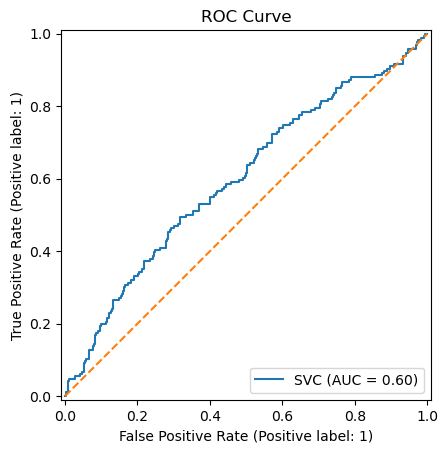

In [197]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
            clf_tuned_2,
            x_test,
            y_test,
            name='SVC')
disp_roc.ax_.set_title('ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')
plt.show()

## 4. tuned model

In [206]:
# Print best parameters
print("\nparameters of tunned model:")
print(rs_2.best_params_)
print(f"Best score: {rs_2.best_score_:.4f}")


parameters of tunned model:
{'kernel': 'rbf', 'class_weight': 'balanced', 'C': 5}
Best score: 0.5102


In [209]:
#predict model
y_predict_train_2 = clf_tuned_2.predict(x_train)
y_predict_test_2 = clf_tuned_2.predict(x_test)

In [210]:
# Accuracy Scores
acc_train = accuracy_score(y_train, y_predict_train_2)
acc_test = accuracy_score(y_test, y_predict_test_2)
print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7319, Test Accuracy: 0.6607


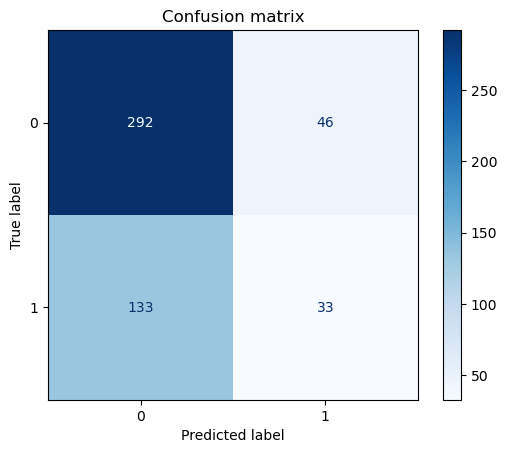

In [211]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        clf_tuned_1,
        x_test,
        y_test,
        display_labels=clf_tuned_1.classes_,
        cmap=plt.cm.Blues
    )
disp.ax_.set_title('Confusion matrix')
plt.show()

In [219]:
# Classification Report
print(classification_report(y_test, y_predict_test_2))

              precision    recall  f1-score   support

           0       0.70      0.87      0.77       338
           1       0.47      0.24      0.32       166

    accuracy                           0.66       504
   macro avg       0.58      0.55      0.55       504
weighted avg       0.62      0.66      0.62       504



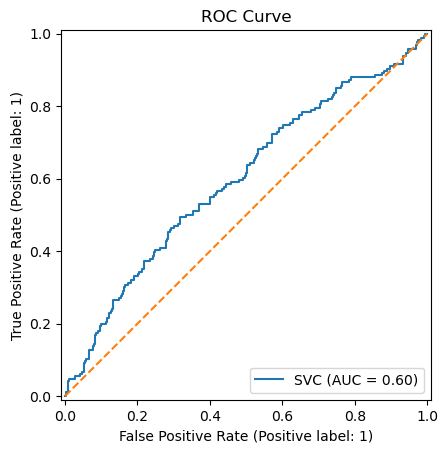

In [218]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
            clf_tuned_2,
            x_test,
            y_test,
            name='SVC')
disp_roc.ax_.set_title('ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')
plt.show()